# Sign Language Recognition on WLASL100 (v2)
**Video → MediaPipe keypoints → spatial encoder → Transformer → sign classifier → gloss-to-text**

**Setup on Kaggle**
1. *Add Data* → search **"WLASL (Processed)"** (by risangbaskoro; contains `videos/`, `nslt_100.json`, `wlasl_class_list.txt`).
2. *Settings → Internet: On* (needed for `pip install mediapipe` and the optional T5 step).
3. Run keypoint extraction once on CPU (cached to `/kaggle/working/kp_all`). Then use a GPU for training.

**What's new in v2**
- Keypoints are extracted from **every frame** of the sign segment (MediaPipe tracking works on consecutive frames); 32 frames are sampled with random jitter at train time. New cache dir `kp_all`, so the old `kp` cache is not reused.
- Hand-local features (wrist-relative, hand-size-normalized, with `z`), explicit detection masks, and interpolation of short detection gaps.
- Mirror augmentation with left/right swap, random detector-dropout, jittered temporal sampling.
- EMA weights, multi-seed ensemble, final retrain on train+val, test-time augmentation, mean ± std over seeds and confidence intervals.
- Stream benchmark (many random concatenations, word error rate) instead of a single demo example.
- Removed duplicate / commented-out cells and the Hugging Face login (the model is public). Outputs are cleared.

In [1]:
# !pip uninstall -y mediapipe tensorflow tensorflow-text tf-keras \
#     opencv-python opencv-python-headless opencv-contrib-python opencv-contrib-python-headless

# !pip install -q \
#     "numpy==1.26.4" \
#     "protobuf==4.25.9" \
#     "tensorflow==2.17.1" \
#     "opencv-python==4.11.0.86" \
#     "mediapipe==0.10.21"

In [2]:
# !pip install --force-reinstall --no-cache-dir \
#     "numpy==1.26.4" \
#     "pandas==2.2.2"

In [3]:
import numpy as np
import pandas as pd

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 1.26.4
Pandas: 2.2.2


In [4]:
from mediapipe.python.solutions import holistic

print("Holistic imported!")
print(holistic.Holistic)

2026-10-02 02:32:09.240817: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-10-02 02:32:09.263717: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-10-02 02:32:09.270804: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.5.3, so it will not be used.
  warnings.warn(


Holistic imported!
<class 'mediapipe.python.solutions.holistic.Holistic'>


In [5]:
import mediapipe.python.solutions as solutions

print("solutions imported!")
print(hasattr(solutions, "holistic"))

solutions imported!
True


In [6]:
import os, glob, json, math, random, time, copy, warnings
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.swa_utils import AveragedModel, get_ema_multi_avg_fn
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

T = 32                     # frames per clip fed to the model
KP_DIR = "/kaggle/working/kp_all"   # all-frames keypoint cache (v2)
os.makedirs(KP_DIR, exist_ok=True)
print("device:", DEVICE, "| cpus:", os.cpu_count())

device: cuda | cpus: 4


In [7]:
nslt_path = glob.glob("/kaggle/input/datasets/risangbaskoro/wlasl-processed/nslt_100.json", recursive=True)[0]
ROOT = os.path.dirname(nslt_path)
VID_DIR = os.path.join(ROOT, "videos")
nslt = json.load(open(nslt_path))

classes = {}
for line in open(os.path.join(ROOT, "wlasl_class_list.txt")):
    i, g = line.strip().split("\t")
    classes[int(i)] = g
GLOSSES = [classes[i] for i in range(100)]

rows = []
for vid, info in nslt.items():
    path = os.path.join(VID_DIR, f"{vid}.mp4")
    if os.path.exists(path):
        label, start, end = info["action"]
        rows.append(dict(vid=vid, subset=info["subset"], label=label, start=start, end=end, path=path))
df = pd.DataFrame(rows)
print(df.subset.value_counts().to_dict(), "| classes:", df.label.nunique())
df.head()

{'train': 748, 'val': 165, 'test': 100} | classes: 100


,vid,subset,label,start,end,path
0,69422,val,27,1,51,/kaggle/input/datasets/risangbaskoro/wlasl-pro...
1,10898,val,82,1,39,/kaggle/input/datasets/risangbaskoro/wlasl-pro...
2,10893,train,82,1,50,/kaggle/input/datasets/risangbaskoro/wlasl-pro...
3,10892,train,82,1,203,/kaggle/input/datasets/risangbaskoro/wlasl-pro...
4,10895,train,82,1,108,/kaggle/input/datasets/risangbaskoro/wlasl-pro...


## 2. Data pipeline — frame preprocessing + keypoint detection
For each clip we:
- crop to the annotated sign segment (`start`/`end`),
- run **MediaPipe Holistic on every frame, in order** (so its tracker works as intended),
- keep 7 upper-body pose points + 21 left-hand + 21 right-hand points as (x, y, z) = 49 points.

Undetected points are stored as NaN (no more copying the previous detection) and handled in normalization.

In [8]:
POSE_IDX = [0, 11, 12, 13, 14, 15, 16]   # nose, shoulders, elbows, wrists
NPTS = 7 + 21 + 21

def extract_video(path, start=0, end=-1):
    """Run Holistic on EVERY frame of the sign segment, in order.
    Returns (L, 49, 3) float32 array of (x, y, z); NaN = not detected."""
    import cv2, mediapipe as mp
    cv2.setNumThreads(1)
    cap = cv2.VideoCapture(path)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if n <= 0:
        return None
    s = max(start - 1, 0)
    e = n if (end is None or end <= 0 or end > n) else end
    if e - s < 2:
        s, e = 0, n
    out = np.full((e - s, NPTS, 3), np.nan, np.float32)
    holistic = mp.solutions.holistic.Holistic(static_image_mode=False, model_complexity=1,
                                              min_detection_confidence=0.4, min_tracking_confidence=0.4)
    for i in range(e):
        if not cap.grab():
            break
        if i < s:
            continue
        ok, frame = cap.retrieve()
        if not ok:
            continue
        res = holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        a = out[i - s]
        if res.pose_landmarks:
            for k, j in enumerate(POSE_IDX):
                lm = res.pose_landmarks.landmark[j]; a[k] = (lm.x, lm.y, lm.z)
        if res.left_hand_landmarks:
            a[7:28] = [(l.x, l.y, l.z) for l in res.left_hand_landmarks.landmark]
        if res.right_hand_landmarks:
            a[28:49] = [(l.x, l.y, l.z) for l in res.right_hand_landmarks.landmark]
    cap.release(); holistic.close()
    return out if np.isfinite(out).any() else None

def _job(row):
    out = f"{KP_DIR}/{row['vid']}.npy"
    if os.path.exists(out):
        return True
    try:
        kp = extract_video(row["path"], row["start"], row["end"])
        if kp is None:
            print("NO KEYPOINTS:", row["vid"], row["path"])
            return False
        np.save(out, kp)
        return True
    except Exception as ex:
        print("ERROR:", row["vid"], "|", row["path"], "|", type(ex).__name__, ex)
        return False

In [9]:
# One-off cost: roughly 15-30 min on 4 CPUs (every frame is processed now). Resumable (skips cached files).
from multiprocessing import Pool
jobs = df.to_dict("records")
t0 = time.time()
with Pool(max(1, os.cpu_count())) as pool:
    ok = list(tqdm(pool.imap_unordered(_job, jobs, chunksize=4), total=len(jobs)))
print(f"done in {(time.time()-t0)/60:.1f} min | success {sum(ok)}/{len(ok)}")
df = df[[os.path.exists(f"{KP_DIR}/{v}.npy") for v in df.vid]].reset_index(drop=True)
print(df.subset.value_counts().to_dict())

  0%|          | 0/1013 [00:00<?, ?it/s]

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1790908345.025725     244 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790908345.061904     248 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790908345.071615     236 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790908345.084409     240 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790908345.139228     247 inference_

done in 29.8 min | success 1013/1013
{'train': 748, 'val': 165, 'test': 100}


### Normalization
- Interpolate short detection gaps (≤ 3 frames).
- Center every frame on the mid-shoulder point and scale by shoulder width, so the model is invariant to camera distance and signer position.
- Undetected points become 0 **and** get an explicit mask `M` (0 is also the chest position, so the mask removes the ambiguity).

In [10]:
def normalize(kp):
    """kp: (L, 49, 3) raw, NaN = missing  ->  X (L, 49, 3), M (L, 49).
    X: shoulder-centred, shoulder-width-scaled, missing = 0.  M: 1 where the point was detected."""
    L = len(kp)
    kp = (pd.DataFrame(kp.astype(np.float32).reshape(L, -1))
            .interpolate(limit=3, limit_area="inside").values.reshape(L, NPTS, 3))
    sh = kp[:, 1:3, :2]                                                   # shoulders
    ctr = pd.DataFrame(np.nanmean(sh, axis=1)).interpolate(limit_direction="both").values
    ctr = np.nan_to_num(ctr, nan=0.5)
    wid = np.nanmean(np.linalg.norm(sh[:, 0] - sh[:, 1], axis=-1))
    wid = 0.25 if (not np.isfinite(wid) or wid < 1e-3) else wid
    out = kp.copy()
    out[..., :2] = (kp[..., :2] - ctr[:, None, :]) / wid
    out[..., 2] = kp[..., 2] / wid
    M = np.isfinite(out[..., 0]).astype(np.float32)
    X = np.clip(np.nan_to_num(out, nan=0.0), -5, 5).astype(np.float32)
    return X, M

seqs = [normalize(np.load(f"{KP_DIR}/{v}.npy")) for v in df.vid]   # list of (X (L,49,3), M (L,49))
y = df.label.values
split = df.subset.values

def get_split(name):
    idx = np.where(split == name)[0]
    return [seqs[i] for i in idx], y[idx]

tr_s, tr_y = get_split("train"); va_s, va_y = get_split("val"); te_s, te_y = get_split("test")

lens = np.array([len(s[0]) for s in seqs])
print("clips:", len(seqs), "| frames/clip min/median/max:", lens.min(), int(np.median(lens)), lens.max())
print(f"frames with >=1 hand: {np.mean([((M[:, 7] + M[:, 28]) > 0).mean() for _, M in seqs]):.2%}",
      f"| left: {np.mean([M[:, 7].mean() for _, M in seqs]):.2%} | right: {np.mean([M[:, 28].mean() for _, M in seqs]):.2%}")

clips: 1013 | frames/clip min/median/max: 19 59 195
frames with >=1 hand: 71.64% | left: 36.86% | right: 68.87%


## 3. Dataset + augmentation
- **Training:** random temporal crop + jittered sampling of 32 frames from the full-rate sequence, mirror (with left/right swap), rotation/scale/shift, noise, and random per-frame hand dropout (simulates detector failures).
- **Evaluation:** deterministic uniform sampling; optional test-time views (`orig`, `mirror`, `crop`).
- **Features per frame:** pose xy + velocity + mask; for each hand: global xy + velocity, hand-local xyz (wrist-relative, scaled by hand size) + velocity, and a presence flag.

In [11]:
# indices: 0 nose | 1/2 shoulders | 3/4 elbows | 5/6 wrists | 7:28 left hand | 28:49 right hand
SWAP = [0, 2, 1, 4, 3, 6, 5] + list(range(28, 49)) + list(range(7, 28))

def sample_idx(L, n=T, lo=0.75):
    """Training: random crop (75-100% of the clip) + one random frame from each of n equal bins."""
    span = np.random.uniform(lo, 1.0) * L
    start = np.random.uniform(0, L - span)
    edges = np.linspace(start, start + span, n + 1)
    pos = np.random.uniform(edges[:-1], edges[1:])
    return np.clip(pos.round().astype(int), 0, L - 1)

def view_idx(L, view="orig"):
    if view == "crop":
        return np.linspace(0.08 * (L - 1), 0.92 * (L - 1), T).round().astype(int)
    return np.linspace(0, L - 1, T).round().astype(int)

def mirror(x, m):
    x = x[:, SWAP].copy(); x[..., 0] *= -1          # x is shoulder-centred, so flipping = negating
    return x, m[:, SWAP].copy()

def augment(x, m):
    if np.random.rand() < 0.5:
        x, m = mirror(x, m)
    th = math.radians(np.random.uniform(-15, 15))
    R = np.array([[math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)]], np.float32)
    sc = np.random.uniform(0.85, 1.15)
    x = x.copy()
    x[..., :2] = (x[..., :2] @ R.T) * sc + np.random.uniform(-0.1, 0.1, 2).astype(np.float32)
    x += np.random.randn(*x.shape).astype(np.float32) * 0.01
    m = m.copy()
    for s, e in ((7, 28), (28, 49)):                 # random per-frame hand dropout
        m[np.random.rand(len(x)) < 0.08, s:e] = 0
    return x * m[..., None], m

# ---- feature construction ----
POSE_D = 7 * 2 * 2 + 7                 # xy + vel + mask                              = 35
HAND_D = 21 * 2 * 2 + 21 * 3 * 2 + 1   # global xy + vel, local xyz + vel, presence   = 211

def _vel(a, valid):
    v = np.zeros_like(a)
    v[1:] = (a[1:] - a[:-1]) * 5 * (valid[1:] & valid[:-1])[:, None]
    return v

def _local(h, hm):
    size = np.linalg.norm(h[:, 9, :2] - h[:, 0, :2], axis=-1)[:, None, None]   # wrist -> middle-finger base
    return np.clip((h - h[:, :1]) / np.maximum(size, 0.05), -6, 6) * hm[:, :, None]

def make_features(x, m):
    n = len(x)
    pose = x[:, :7, :2].reshape(n, -1)
    parts = [pose, _vel(pose, m[:, :7].mean(1) > 0.5), m[:, :7]]
    for s, e in ((7, 28), (28, 49)):
        h, hm = x[:, s:e], m[:, s:e]
        ok = hm[:, 0] > 0
        g = h[..., :2].reshape(n, -1)
        loc = _local(h, hm).reshape(n, -1)
        parts += [g, _vel(g, ok), loc, _vel(loc, ok), hm[:, :1]]
    return np.concatenate(parts, -1).astype(np.float32)

class KPDataset(Dataset):
    def __init__(self, seqs, y, train=False, view="orig"):
        self.seqs, self.y, self.train, self.view = seqs, y, train, view
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        x, m = self.seqs[i]
        if self.train:
            idx = sample_idx(len(x)); x, m = x[idx], m[idx]
            x, m = augment(x, m)
        else:
            idx = view_idx(len(x), self.view); x, m = x[idx], m[idx]
            if self.view == "mirror":
                x, m = mirror(x, m)
        return torch.from_numpy(make_features(x, m)), int(self.y[i])

def make_loader(seqs, yy, train, view="orig", bs=64):
    return DataLoader(KPDataset(seqs, yy, train, view), batch_size=bs, shuffle=train,
                      drop_last=train, num_workers=2 if train else 0)

## 4. Deep learning model
- **Spatial feature extraction:** separate MLP encoders for pose / left hand / right hand (global + hand-local features + velocity + masks), fused into one vector per frame.
- **Temporal modeling:** Transformer encoder with a learnable CLS token and positional embeddings.
- **Sign classification:** linear head over the CLS token (100 classes).

In [12]:
class SignTransformer(nn.Module):
    def __init__(self, n_classes=100, d=256, layers=4, heads=8, drop=0.2, hid=128):
        super().__init__()
        def branch(n_in):
            return nn.Sequential(nn.LayerNorm(n_in), nn.Linear(n_in, hid), nn.GELU(), nn.Dropout(drop))
        self.pose, self.lh, self.rh = branch(POSE_D), branch(HAND_D), branch(HAND_D)
        self.fuse = nn.Sequential(nn.Linear(3 * hid, d), nn.LayerNorm(d))
        self.cls = nn.Parameter(torch.zeros(1, 1, d))
        self.pos = nn.Parameter(torch.randn(1, T + 1, d) * 0.02)
        enc = nn.TransformerEncoderLayer(d, heads, d * 2, drop, batch_first=True, norm_first=True, activation="gelu")
        self.temporal = nn.TransformerEncoder(enc, layers)
        self.head = nn.Sequential(nn.LayerNorm(d), nn.Dropout(drop), nn.Linear(d, n_classes))

    def forward(self, x):                         # x: (B, T, POSE_D + 2*HAND_D)
        z = torch.cat([self.pose(x[..., :POSE_D]),
                       self.lh(x[..., POSE_D:POSE_D + HAND_D]),
                       self.rh(x[..., POSE_D + HAND_D:])], -1)
        z = self.fuse(z)
        z = torch.cat([self.cls.expand(len(z), -1, -1), z], 1) + self.pos
        return self.head(self.temporal(z)[:, 0])

print(f"{sum(p.numel() for p in SignTransformer().parameters())/1e6:.2f}M params | feature dim {POSE_D + 2 * HAND_D}")

2.30M params | feature dim 457


## 5. Training
- Each model uses **EMA weights** (smoother, usually better than the raw last weights).
- **Stage A:** `N_SEEDS` models on train only, best EMA checkpoint picked on val → gives mean ± std over seeds (single-seed differences of a few points are noise on a 100-clip test set).
- **Stage B (optional):** retrain `N_SEEDS` models on train+val for a fixed number of epochs (more data, same recipe) and use these as the final ensemble.
- Lower `N_SEEDS` or set `FINAL_TRAINVAL = False` for a faster run.

In [13]:
EPOCHS, N_SEEDS, BS = 100, 5, 64
FINAL_TRAINVAL = True
VIEWS = ("orig", "mirror", "crop")

@torch.no_grad()
def get_probs(model, seqs, yy, view="orig"):
    model.eval(); out = []
    for xb, _ in make_loader(seqs, yy, False, view, 128):
        out.append(F.softmax(model(xb.to(DEVICE)), -1).cpu())
    return torch.cat(out).numpy()

def acc_from_probs(p, yy):
    top1 = float((p.argmax(1) == yy).mean())
    top5 = float(np.mean([yy[i] in np.argsort(-p[i])[:5] for i in range(len(yy))]))
    return top1, top5

def ens_probs(models, seqs, yy, views=VIEWS):
    return np.mean([get_probs(m, seqs, yy, v) for m in models for v in views], 0)

def train_one(seed, tr_s, tr_y, va_s=None, va_y=None, epochs=EPOCHS, verbose=True):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    dl = make_loader(tr_s, tr_y, True, bs=BS)
    model = SignTransformer().to(DEVICE)
    ema = AveragedModel(model, multi_avg_fn=get_ema_multi_avg_fn(0.99))
    opt = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=5e-4, total_steps=epochs * len(dl))
    crit = nn.CrossEntropyLoss(label_smoothing=0.1)
    best, best_state, hist = -1, None, []
    for ep in range(1, epochs + 1):
        model.train(); tl = 0
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); ema.update_parameters(model); tl += loss.item()
        rec = [tl / len(dl)]
        if va_s is not None:
            v1, v5 = acc_from_probs(get_probs(ema.module, va_s, va_y), va_y)
            rec += [v1, v5]
            if v1 > best:
                best, best_state = v1, copy.deepcopy(ema.module.state_dict())
        hist.append(rec)
        if verbose and (ep % 20 == 0 or ep == 1):
            msg = f"  seed {seed} ep {ep:3d} | loss {rec[0]:.3f}"
            if va_s is not None:
                msg += f" | val top1 {rec[1]:.3f} top5 {rec[2]:.3f} | best {best:.3f}"
            print(msg)
    final = SignTransformer().to(DEVICE)
    final.load_state_dict(best_state if va_s is not None else ema.module.state_dict())
    return final.eval(), best, np.array(hist)

In [14]:
# ---- Stage A: train-only models, checkpoint picked on val ----
models_A, hists_A, rows_A = [], [], []
t0 = time.time()
for sd in range(N_SEEDS):
    m, bv, h = train_one(SEED + sd, tr_s, tr_y, va_s, va_y)
    models_A.append(m); hists_A.append(h)
    t1, t5 = acc_from_probs(get_probs(m, te_s, te_y), te_y)
    rows_A.append((bv, t1, t5))
    print(f"seed {SEED + sd}: best val {bv:.3f} | test top1 {t1:.3f} top5 {t5:.3f}")
r = np.array(rows_A)
print(f"\nsingle model over {N_SEEDS} seeds | val {r[:,0].mean():.3f}±{r[:,0].std():.3f} | "
      f"test top1 {r[:,1].mean():.3f}±{r[:,1].std():.3f} | test top5 {r[:,2].mean():.3f}±{r[:,2].std():.3f}")
print(f"stage A took {(time.time() - t0) / 60:.1f} min")

  seed 42 ep   1 | loss 4.777 | val top1 0.000 top5 0.061 | best 0.000
  seed 42 ep  20 | loss 2.766 | val top1 0.273 top5 0.576 | best 0.273
  seed 42 ep  40 | loss 1.366 | val top1 0.709 top5 0.921 | best 0.709
  seed 42 ep  60 | loss 1.022 | val top1 0.770 top5 0.945 | best 0.770
  seed 42 ep  80 | loss 0.917 | val top1 0.806 top5 0.927 | best 0.806
  seed 42 ep 100 | loss 0.897 | val top1 0.836 top5 0.933 | best 0.836
seed 42: best val 0.836 | test top1 0.710 top5 0.940
  seed 43 ep   1 | loss 4.797 | val top1 0.006 top5 0.030 | best 0.006
  seed 43 ep  20 | loss 2.797 | val top1 0.279 top5 0.630 | best 0.279
  seed 43 ep  40 | loss 1.356 | val top1 0.691 top5 0.921 | best 0.697
  seed 43 ep  60 | loss 1.027 | val top1 0.776 top5 0.939 | best 0.782
  seed 43 ep  80 | loss 0.917 | val top1 0.788 top5 0.939 | best 0.806
  seed 43 ep 100 | loss 0.891 | val top1 0.806 top5 0.939 | best 0.806
seed 43: best val 0.806 | test top1 0.720 top5 0.930
  seed 44 ep   1 | loss 4.772 | val top1 0

In [15]:
# ---- Stage B: retrain on train+val with a fixed budget (no checkpoint selection) ----
models_B = []
if FINAL_TRAINVAL:
    tv_s, tv_y = tr_s + va_s, np.concatenate([tr_y, va_y])
    t0 = time.time()
    for sd in range(N_SEEDS):
        m, _, _ = train_one(1000 + SEED + sd, tv_s, tv_y, epochs=EPOCHS)
        models_B.append(m)
    print(f"stage B took {(time.time() - t0) / 60:.1f} min")
FINAL_MODELS = models_B if FINAL_TRAINVAL else models_A
print("final ensemble size:", len(FINAL_MODELS))

  seed 1042 ep   1 | loss 4.750
  seed 1042 ep  20 | loss 2.647
  seed 1042 ep  40 | loss 1.261
  seed 1042 ep  60 | loss 0.992
  seed 1042 ep  80 | loss 0.902
  seed 1042 ep 100 | loss 0.880
  seed 1043 ep   1 | loss 4.766
  seed 1043 ep  20 | loss 2.600
  seed 1043 ep  40 | loss 1.266
  seed 1043 ep  60 | loss 1.007
  seed 1043 ep  80 | loss 0.905
  seed 1043 ep 100 | loss 0.893
  seed 1044 ep   1 | loss 4.792
  seed 1044 ep  20 | loss 2.584
  seed 1044 ep  40 | loss 1.265
  seed 1044 ep  60 | loss 0.988
  seed 1044 ep  80 | loss 0.903
  seed 1044 ep 100 | loss 0.883
  seed 1045 ep   1 | loss 4.771
  seed 1045 ep  20 | loss 2.599
  seed 1045 ep  40 | loss 1.272
  seed 1045 ep  60 | loss 1.012
  seed 1045 ep  80 | loss 0.907
  seed 1045 ep 100 | loss 0.886
  seed 1046 ep   1 | loss 4.830
  seed 1046 ep  20 | loss 2.629
  seed 1046 ep  40 | loss 1.286
  seed 1046 ep  60 | loss 1.014
  seed 1046 ep  80 | loss 0.901
  seed 1046 ep 100 | loss 0.885
stage B took 5.0 min
final ensemble size

## 6. Evaluation
Test accuracy for: one model, the ensemble, and ensemble + test-time augmentation. The test set has only 100 clips, so the 95% CI is wide (roughly ±9 points); treat gaps of 1-3 points as noise.

single model (seed 0)    views=orig               test top-1 0.710 (±0.089, 95% CI) | top-5 0.940
single model (seed 0)    views=orig+mirror+crop   test top-1 0.730 (±0.087, 95% CI) | top-5 0.930
ensemble, train only     views=orig               test top-1 0.750 (±0.085, 95% CI) | top-5 0.940
ensemble, train only     views=orig+mirror+crop   test top-1 0.760 (±0.084, 95% CI) | top-5 0.940
ensemble, train+val      views=orig               test top-1 0.810 (±0.077, 95% CI) | top-5 0.950
ensemble, train+val      views=orig+mirror+crop   test top-1 0.810 (±0.077, 95% CI) | top-5 0.950


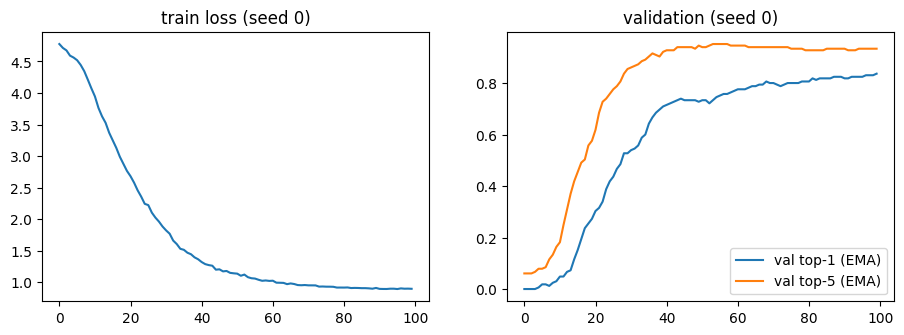

Most confused (true -> predicted): [(('before', 'enjoy'), 1), (('want', 'many'), 1), (('same', 'like'), 1), (('before', 'last'), 1), (('kiss', 'eat'), 1), (('dark', 'decide'), 1), (('but', 'pizza'), 1), (('fine', 'what'), 1)]


In [16]:
def report(name, models):
    for views in (("orig",), VIEWS):
        p = ens_probs(models, te_s, te_y, views)
        t1, t5 = acc_from_probs(p, te_y)
        ci = 1.96 * math.sqrt(t1 * (1 - t1) / len(te_y))
        print(f"{name:24s} views={'+'.join(views):18s} test top-1 {t1:.3f} (±{ci:.3f}, 95% CI) | top-5 {t5:.3f}")

report("single model (seed 0)", models_A[:1])
report("ensemble, train only", models_A)
if FINAL_TRAINVAL:
    report("ensemble, train+val", models_B)

import matplotlib.pyplot as plt
h = hists_A[0]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(h[:, 0]); ax[0].set_title("train loss (seed 0)")
ax[1].plot(h[:, 1], label="val top-1 (EMA)"); ax[1].plot(h[:, 2], label="val top-5 (EMA)")
ax[1].legend(); ax[1].set_title("validation (seed 0)")
plt.show()

from collections import Counter
p_final = ens_probs(FINAL_MODELS, te_s, te_y)
pairs = Counter((GLOSSES[a], GLOSSES[b]) for a, b in zip(te_y.tolist(), p_final.argmax(1).tolist()) if a != b)
print("Most confused (true -> predicted):", pairs.most_common(8))

## 7. Inference: keypoint stream → gloss sequence
A sliding window runs over a keypoint sequence (full frame rate), averages the ensemble's probabilities, keeps confident windows and merges repeats. The benchmark concatenates random test clips and scores the output with word error rate.

**Caveat:** the model was trained on isolated, already-segmented signs. It has no "no-sign / transition" class, so sliding-window output on real continuous video will be noisier than the isolated-clip accuracy suggests.

In [17]:
@torch.no_grad()
def predict_stream(seq, win, stride=None, thr=0.5, min_run=1, models=None):
    """seq = (X (L,49,3), M (L,49)) from normalize(); win/stride are in frames. Returns [(gloss, mean_conf), ...]."""
    models = models or FINAL_MODELS
    X_, M_ = seq
    L = len(X_)
    stride = stride or max(1, win // 4)
    starts = list(range(0, max(L - win, 0) + 1, stride))
    feats = []
    for s in starts:
        idx = np.linspace(s, min(s + win, L) - 1, T).round().astype(int)
        feats.append(make_features(X_[idx], M_[idx]))
    xb = torch.from_numpy(np.stack(feats)).to(DEVICE)
    probs = np.mean([F.softmax(m.eval()(xb), -1).cpu().numpy() for m in models], 0)
    conf, ids = probs.max(1), probs.argmax(1)

    out, run = [], []
    def flush():
        if run and len(run) >= min_run:
            out.append((GLOSSES[run[0][0]], float(np.mean([r[1] for r in run]))))
    for c, i in zip(conf, ids):
        if c >= thr and run and run[-1][0] == i:
            run.append((i, c))
        else:
            flush(); run = [(i, c)] if c >= thr else []
    flush()
    return out

def predict_video(path, win=48, thr=0.5, **kw):
    kp = extract_video(path, 0, -1)                       # every frame
    return predict_stream(normalize(kp), win=win, thr=thr, **kw)

def edit_distance(a, b):
    d = list(range(len(b) + 1))
    for i, x in enumerate(a, 1):
        prev, d[0] = d[0], i
        for j, yv in enumerate(b, 1):
            prev, d[j] = d[j], min(d[j] + 1, d[j - 1] + 1, prev + (x != yv))
    return d[-1]

test_ids = np.where(split == "test")[0]

def make_stream(pick):
    return (np.concatenate([seqs[i][0] for i in pick]), np.concatenate([seqs[i][1] for i in pick]))

def stream_benchmark(n_trials=200, k=3, thr=0.3, seed=0):
    rng = np.random.RandomState(seed); errs = exact = 0
    for _ in range(n_trials):
        pick = rng.choice(test_ids, k, replace=False)
        win = int(np.median([len(seqs[i][0]) for i in pick]))
        pred = [g for g, _ in predict_stream(make_stream(pick), win=win, thr=thr)]
        d = edit_distance([GLOSSES[i] for i in y[pick]], pred)
        errs += d; exact += (d == 0)
    print(f"stream benchmark ({n_trials} random {k}-sign concatenations, thr={thr}): "
          f"WER {errs / (n_trials * k):.3f} | exact-sequence accuracy {exact / n_trials:.3f}")

# Demo on one random concatenation
rng = np.random.RandomState(1)
pick = rng.choice(test_ids, 3, replace=False)
win = int(np.median([len(seqs[i][0]) for i in pick]))
print("ground truth :", [GLOSSES[y[i]] for i in pick])
glosses = predict_stream(make_stream(pick), win=win, thr=0.3)
print("predicted    :", glosses)

stream_benchmark()

ground truth : ['short', 'purple', 'woman']
predicted    : [('purple', 0.9091176986694336), ('bowling', 0.42858728766441345), ('mother', 0.494241327047348), ('man', 0.34254133701324463), ('woman', 0.5438829660415649)]
stream benchmark (200 random 3-sign concatenations, thr=0.3): WER 0.412 | exact-sequence accuracy 0.200


## 8. Language processing — grammar / context refinement
**Important caveat:** WLASL is *isolated* signs with no sentence labels, so there is nothing to train a gloss-to-sentence model on here. This step is therefore (a) rule-based cleanup and (b) an optional pretrained FLAN-T5 that rewrites the gloss sequence into a fluent sentence. With only isolated words as input it can only guess a plausible sentence (and may invent words), so treat it as a demo. For true sentence-level translation you need a continuous dataset (How2Sign, PHOENIX-2014T).

In [18]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "google/flan-t5-base"           # public model, no Hugging Face login/token needed
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE).eval()

def rule_based(glosses):
    words = []
    for g in glosses:
        g = g.lower().strip()
        if not words or words[-1] != g:      # drop consecutive duplicates
            words.append(g)
    if not words:
        return ""
    s = " ".join(words)
    return s[0].upper() + s[1:] + "."

def llm_refine(glosses):
    """Convert predicted sign-language glosses into a short English sentence."""
    if not glosses:
        return ""
    try:
        prompt = ("Rewrite these sign-language glosses as one short, grammatical English sentence: "
                  + " ".join(g.upper() for g in glosses))
        inputs = {k: v.to(DEVICE) for k, v in tokenizer(prompt, return_tensors="pt").items()}
        with torch.no_grad():
            outputs = t5_model.generate(**inputs, max_new_tokens=32, num_beams=4)
        return tokenizer.decode(outputs[0], skip_special_tokens=True)
    except Exception as ex:
        print("T5 unavailable, using rules:", type(ex).__name__)
        return rule_based(glosses)

def to_text(pred, use_llm=True, min_conf=0.0):
    """pred = [(gloss, confidence), ...]"""
    gl = [g for g, c in pred if c >= min_conf]
    return llm_refine(gl) if (use_llm and gl) else rule_based(gl)

print("rules:", to_text(glosses, use_llm=False))
print("T5   :", to_text(glosses, use_llm=True))

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

rules: Purple bowling mother man woman.
T5   : PURPLE BOWLING MOTHER MAN WOMAN


## 9. Save artifacts

In [19]:
json.dump(GLOSSES, open("/kaggle/working/glosses.json", "w"))
json.dump(dict(T=T, n_classes=100, pose_idx=POSE_IDX, pose_d=POSE_D, hand_d=HAND_D,
               views=list(VIEWS), swap=SWAP), open("/kaggle/working/config.json", "w"))
torch.save({"states": [m.state_dict() for m in FINAL_MODELS], "T": T}, "/kaggle/working/ensemble.pt")
print(os.listdir("/kaggle/working"))
# Note: for deployment, move normalize / make_features / SignTransformer / predict_stream into a .py module.

['config.json', 'kp_all', 'glosses.json', '.virtual_documents', 'ensemble.pt']


## Notes / next steps
- **Already done in v2:** all-frame extraction, hand-local features + masks, mirror/dropout augmentation, EMA, seed ensemble, train+val retrain, TTA, stream benchmark.
- **Still worth trying:** add face/mouth points (many signs differ by mouth shape); ST-GCN or a hand-structure-aware encoder; self-supervised pretraining on the keypoints; a "no-sign / transition" class trained on partial windows so sliding-window output improves.
- **Evaluation:** report mean ± std over seeds and CIs; the official WLASL split is not signer-independent (as far as I know), so accuracy partly reflects signer familiarity. Verify any published numbers you quote against the papers.
- **Real sentences:** train on continuous data (PHOENIX-2014T, How2Sign) with CTC or seq2seq, using this encoder as the backbone.